In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import r2_score, mean_absolute_percentage_error

pd.set_option("display.max_columns", None)

In [4]:
pred_path = Path("week7_xgboost_test_predictions.csv")

if not pred_path.exists():
    raise FileNotFoundError(
        "Missing week7_xgboost_test_predictions.csv. "
        "Go back to 05_advanced_models.ipynb and save the XGBoost test predictions first."
    )

eval_df = pd.read_csv(pred_path, low_memory=False)

print("Loaded:", pred_path)
print("Shape:", eval_df.shape)
eval_df.head()

Loaded: week7_xgboost_test_predictions.csv
Shape: (12858, 100)


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,BuyerAgencyCompensationType,StreetNumberNumeric,ListingId,Bathrooms,City,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,Bedrooms,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSize,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,source_file,BuyerAgentAOR,ListAgentAOR,CloseMonth,LivingArea_missing,Bedrooms_missing,Bathrooms_missing,LotSize_missing,BedBathRatio,TotalRoomsProxy,log_LivingArea,log_LotSize,PropertyAge,row_id,DistrictName,HasUnifiedDistrict,DistrictName_Grouped,PredictedClosePrice_XGB,AbsoluteError_XGB,APE_XGB
0,NaN,False,NaN,NaN,NaN,1199000.0,1159602306,derek@listingsv.com,2026-06-01,1310000.0,Derek,Essary,37.229810,-121.794499,6489 San Anselmo Way,Residential,1779.0,1199000.0,5.0,Coldwell Banker Realty,"David Phan, Broker",Coldwell Banker Realty,Derek Essary,Brittany,Walker,ML5101195,David,Phan,NaN,Quarterly,NaN,1.159602e+09,699 - Not Defined,NaN,Santa Clara,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,0.1377,NaN,Mlslistings,1973.0,NaN,6489.0,ML82046165,2.0,San Jose,NaN,NaN,NaN,2.0,2026-06-01,NaN,NaN,2026-05-12,2026-05-07,NaN,NaN,CA,NaN,NaN,True,NaN,NaN,NaN,NaN,6000.00,NaN,False,2.0,Other,95119,150.00,6000.0,NaN,NaN,NaN,CRMLSSold202606.csv,Mlslistings,Mlslistings,2026-06,0,0,0,0,1.0,4.0,7.484369,8.699681,53.0,399572,Unknown,0,Unknown,1064613.5,245386.5000,0.187318
1,"Laminate,Wood",True,NaN,NaN,False,575000.0,1155415053,blaine.ostrander@redfin.com,2026-06-01,540000.0,Blaine,Ostrander,34.281356,-118.730369,3403 Highwood Court 154,Residential,1051.0,549999.0,42.0,Redfin Corporation,ROA CALIFORNIA INC.,Redfin Corporation,Blaine Ostrander,Kelly,Bond-Ostrander,IVLOPEALE,ALEJANDRA,LOPEZ,NaN,Monthly,NaN,1.155415e+09,SVC - Central Simi,NaN,Ventura,Closed,NaN,False,2.0,NaN,SingleFamilyResidence,0.0200,Meadowbrooks ATT (222),InlandValleys,1974.0,NaN,3403.0,BB26051702,2.0,Simi Valley,NaN,NaN,NaN,3.0,2026-06-01,NaN,NaN,2026-04-29,2026-03-18,NaN,NaN,CA,NaN,NaN,False,1.0,NaN,One,NaN,871.00,3.0,False,2.0,Simi Valley Unified,93063,343.13,871.0,NaN,NaN,NaN,CRMLSSold202606.csv,InlandValleys,Burbank,2026-06,0,0,0,0,1.5,5.0,6.958448,6.770789,52.0,399551,Simi Valley Unified,1,Simi Valley Unified,749288.2,209288.1875,0.387571
2,"Carpet,Laminate,Tile",False,NaN,NaN,False,1290000.0,1159566082,shane@calmutualhomes.com,2026-06-01,1440000.0,Shane,Dailey,33.691520,-117.902133,3267 Turlock Drive,Residential,1884.0,1360000.0,8.0,Cal Mutual Inc,Cal Mutual Inc.,NaN,Shane Dailey,NaN,NaN,TRDAILDEN,Dennis,Dailey,NaN,NaN,NaN,1.159566e+09,C3 - South Coast Metro,NaN,Orange,Closed,NaN,NaN,3.0,NaN,SingleFamilyResidence,0.1377,NaN,NaN,1972.0,NaN,3267.0,26830611,2.0,Costa Mesa,NaN,NaN,1884.0,4.0,2026-06-01,NaN,NaN,2026-05-15,2026-05-06,NaN,NaN,CA,NaN,NaN,True,1.0,NaN,One,60x100,6000.00,NaN,False,3.0,NaN,92626,NaN,6000.0,NaN,NaN,NaN,CRMLSSold202606.csv,NaN,OutOfAreaBoard,2026-06,0,0,0,0,2.0,6.0,7.541683,8.699681,54.0,399550,Newport-Mesa Unified,1,Newport-Mesa Unified,1657414.9,217414.8750,0.150983
3,NaN,True,NaN,NaN,False,875000.0,1159553708,deborahmsee@gmail.com,2026-06-01,890000.0,Debo

In [5]:
eval_df["CloseDate"] = pd.to_datetime(eval_df["CloseDate"], errors="coerce")

numeric_cols = [
    "ClosePrice",
    "PredictedClosePrice_XGB",
    "AbsoluteError_XGB",
    "APE_XGB"
]

for col in numeric_cols:
    eval_df[col] = pd.to_numeric(eval_df[col], errors="coerce")

eval_df = eval_df.dropna(subset=["ClosePrice", "PredictedClosePrice_XGB"]).copy()

print("Date range:", eval_df["CloseDate"].min(), "to", eval_df["CloseDate"].max())
print("Rows:", len(eval_df))

Date range: 2026-06-01 00:00:00 to 2026-06-30 00:00:00
Rows: 12858


In [6]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    mask = y_true != 0
    y_true_nonzero = y_true[mask]
    y_pred_nonzero = y_pred[mask]
    
    return {
        "R2": r2_score(y_true, y_pred),
        "MAPE": mean_absolute_percentage_error(y_true_nonzero, y_pred_nonzero),
        "MdAPE": np.median(np.abs((y_true_nonzero - y_pred_nonzero) / y_true_nonzero)),
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
        "Count": len(y_true)
    }

In [7]:
overall_metrics = regression_metrics(
    eval_df["ClosePrice"],
    eval_df["PredictedClosePrice_XGB"]
)

overall_metrics_df = pd.DataFrame([{
    "Segment": "Overall",
    **overall_metrics
}])

overall_metrics_df["MAPE_%"] = overall_metrics_df["MAPE"] * 100
overall_metrics_df["MdAPE_%"] = overall_metrics_df["MdAPE"] * 100

overall_metrics_df

,Segment,R2,MAPE,MdAPE,MAE,RMSE,Count,MAPE_%,MdAPE_%
0,Overall,0.615317,0.369118,0.199597,377141.259385,952920.219385,12858,36.911806,19.959747


In [8]:
price_bins = [0, 500_000, 1_000_000, 2_000_000, np.inf]

price_labels = [
    "Under $500K",
    "$500K–$1M",
    "$1M–$2M",
    "$2M+"
]

eval_df["PriceBand"] = pd.cut(
    eval_df["ClosePrice"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True,
    right=False
)

eval_df["PriceBand"].value_counts().reindex(price_labels)

PriceBand
Under $500K    1767
$500K–$1M      5312
$1M–$2M        3987
$2M+           1792
Name: count, dtype: int64

In [9]:
price_band_counts = (
    eval_df["PriceBand"]
    .value_counts()
    .reindex(price_labels)
    .reset_index()
)

price_band_counts.columns = ["PriceBand", "Count"]
price_band_counts["Percent"] = price_band_counts["Count"] / len(eval_df) * 100

price_band_counts

,PriceBand,Count,Percent
0,Under $500K,1767,13.742417
1,$500K–$1M,5312,41.312801
2,$1M–$2M,3987,31.007933
3,$2M+,1792,13.936849


In [10]:
band_metric_rows = []

for band in price_labels:
    subset = eval_df[eval_df["PriceBand"] == band].copy()
    
    if len(subset) == 0:
        continue
    
    metrics = regression_metrics(
        subset["ClosePrice"],
        subset["PredictedClosePrice_XGB"]
    )
    
    band_metric_rows.append({
        "Segment": band,
        **metrics
    })

price_band_metrics = pd.DataFrame(band_metric_rows)

price_band_metrics["MAPE_%"] = price_band_metrics["MAPE"] * 100
price_band_metrics["MdAPE_%"] = price_band_metrics["MdAPE"] * 100

price_band_metrics

,Segment,R2,MAPE,MdAPE,MAE,RMSE,Count,MAPE_%,MdAPE_%
0,Under $500K,-7.164908,1.203418,0.396036,1.912434e+05,2.542067e+05,1767,120.341773,39.603576
1,$500K–$1M,-1.524153,0.216156,0.156274,1.550131e+05,2.221735e+05,5312,21.615632,15.627394
2,$1M–$2M,-1.360491,0.217696,0.183390,3.088899e+05,4.141371e+05,3987,21.769643,18.338968
3,$2M+,0.358410,0.336776,0.313974,1.370749e+06,2.433903e+06,1792,33.677617,31.397384


In [11]:
price_band_error_summary = eval_df.groupby("PriceBand", observed=True).agg(
    count=("ClosePrice", "count"),
    median_actual_price=("ClosePrice", "median"),
    mean_actual_price=("ClosePrice", "mean"),
    median_predicted_price=("PredictedClosePrice_XGB", "median"),
    mean_predicted_price=("PredictedClosePrice_XGB", "mean"),
    median_absolute_error=("AbsoluteError_XGB", "median"),
    mean_absolute_error=("AbsoluteError_XGB", "mean"),
    median_ape=("APE_XGB", "median"),
    mean_ape=("APE_XGB", "mean")
).reset_index()

price_band_error_summary["median_ape_%"] = price_band_error_summary["median_ape"] * 100
price_band_error_summary["mean_ape_%"] = price_band_error_summary["mean_ape"] * 100

price_band_error_summary

,PriceBand,count,median_actual_price,mean_actual_price,median_predicted_price,mean_predicted_price,median_absolute_error,mean_absolute_error,median_ape,mean_ape,median_ape_%,mean_ape_%
0,Under $500K,1767,400000.0,3.813450e+05,535809.06,5.665127e+05,145819.34375,1.912434e+05,0.396036,1.203418,39.603574,120.341773
1,$500K–$1M,5312,745000.0,7.414341e+05,807903.83,8.314680e+05,113474.75000,1.550131e+05,0.156274,0.216156,15.627397,21.615632
2,$1M–$2M,3987,1350000.0,1.397541e+06,1192375.50,1.262194e+06,247171.75000,3.088899e+05,0.183390,0.217696,18.338966,21.769643
3,$2M+,1792,2820000.0,3.687231e+06,2060949.20,2.480992e+06,927181.93750,1.370749e+06,0.313974,0.336776,31.397384,33.677617


In [12]:
metrics_summary = price_band_metrics.copy()

metrics_summary = metrics_summary[
    ["Segment", "Count", "R2", "MAPE", "MdAPE", "MAPE_%", "MdAPE_%", "MAE", "RMSE"]
]

metrics_summary = pd.concat(
    [overall_metrics_df[metrics_summary.columns], metrics_summary],
    ignore_index=True
)

metrics_summary.to_csv("metrics_summary.csv", index=False)

metrics_summary

,Segment,Count,R2,MAPE,MdAPE,MAPE_%,MdAPE_%,MAE,RMSE
0,Overall,12858,0.615317,0.369118,0.199597,36.911806,19.959747,3.771413e+05,9.529202e+05
1,Under $500K,1767,-7.164908,1.203418,0.396036,120.341773,39.603576,1.912434e+05,2.542067e+05
2,$500K–$1M,5312,-1.524153,0.216156,0.156274,21.615632,15.627394,1.550131e+05,2.221735e+05
3,$1M–$2M,3987,-1.360491,0.217696,0.183390,21.769643,18.338968,3.088899e+05,4.141371e+05
4,$2M+,1792,0.358410,0.336776,0.313974,33.677617,31.397384,1.370749e+06,2.433903e+06


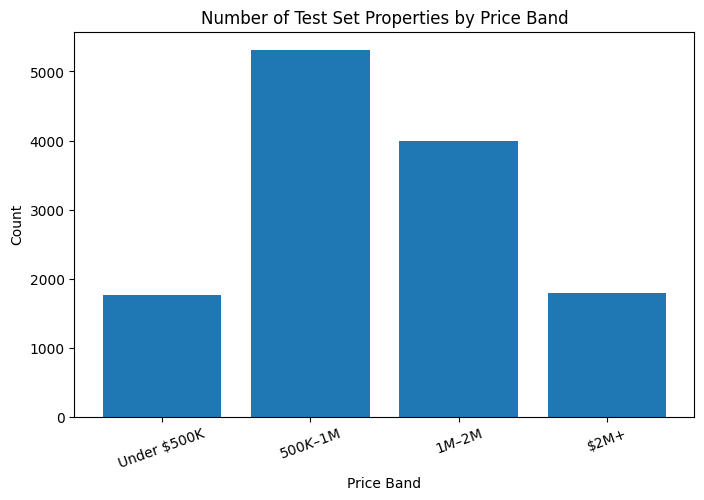

In [13]:
plt.figure(figsize=(8, 5))

plt.bar(
    price_band_counts["PriceBand"],
    price_band_counts["Count"]
)

plt.title("Number of Test Set Properties by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

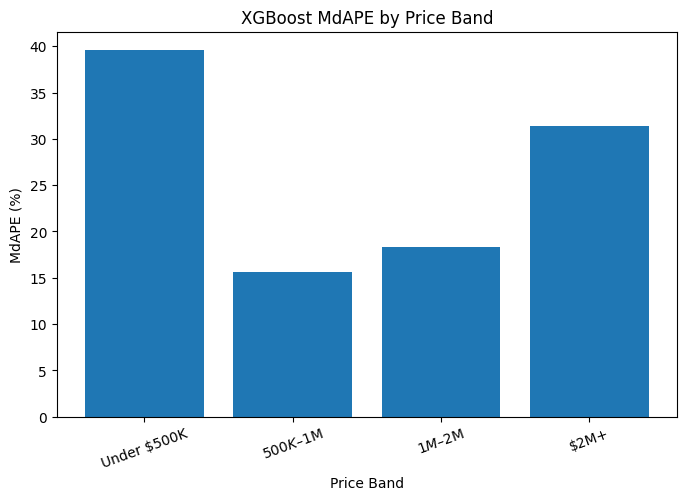

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    price_band_metrics["Segment"].astype(str),
    price_band_metrics["MdAPE_%"]
)

plt.title("XGBoost MdAPE by Price Band")
plt.xlabel("Price Band")
plt.ylabel("MdAPE (%)")
plt.xticks(rotation=20)
plt.show()

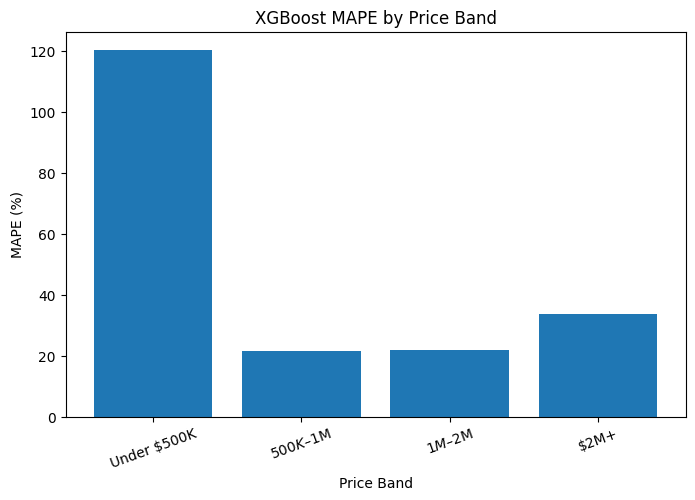

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    price_band_metrics["Segment"],
    price_band_metrics["MAPE_%"]
)

plt.title("XGBoost MAPE by Price Band")
plt.xlabel("Price Band")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=20)
plt.show()

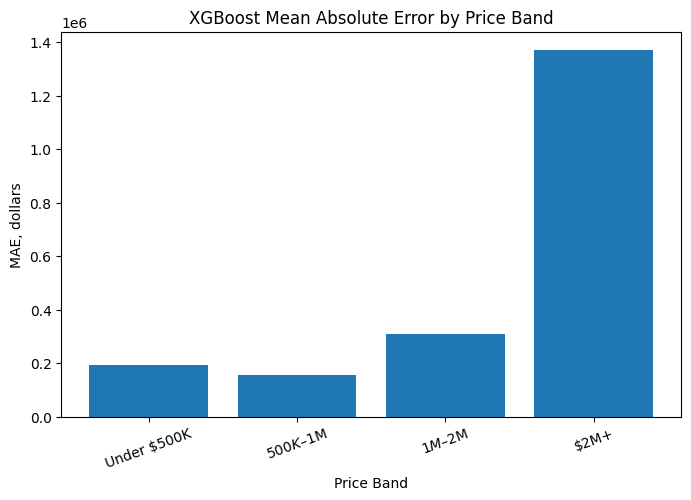

In [16]:
plt.figure(figsize=(8, 5))

plt.bar(
    price_band_metrics["Segment"],
    price_band_metrics["MAE"]
)

plt.title("XGBoost Mean Absolute Error by Price Band")
plt.xlabel("Price Band")
plt.ylabel("MAE, dollars")
plt.xticks(rotation=20)
plt.show()

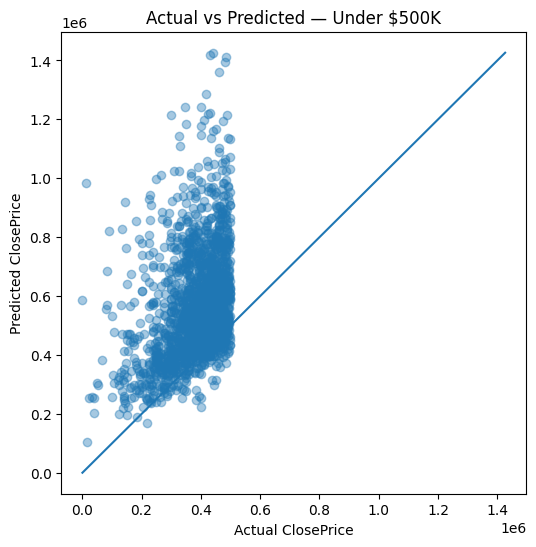

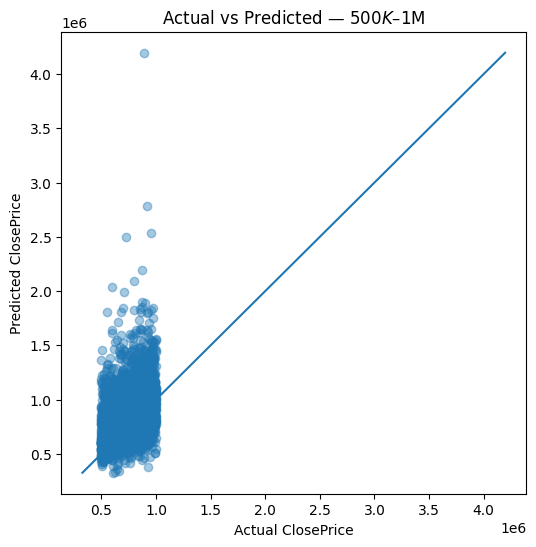

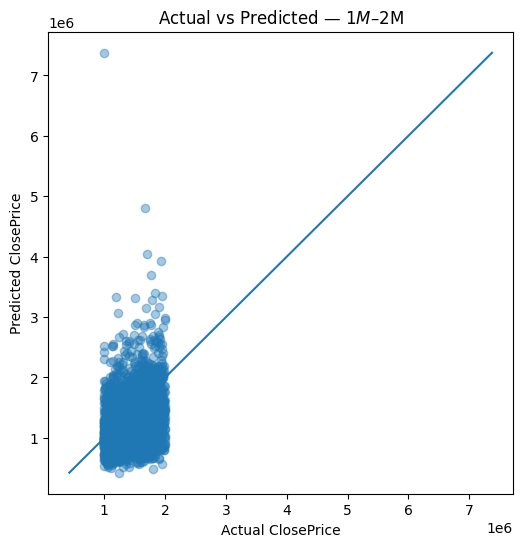

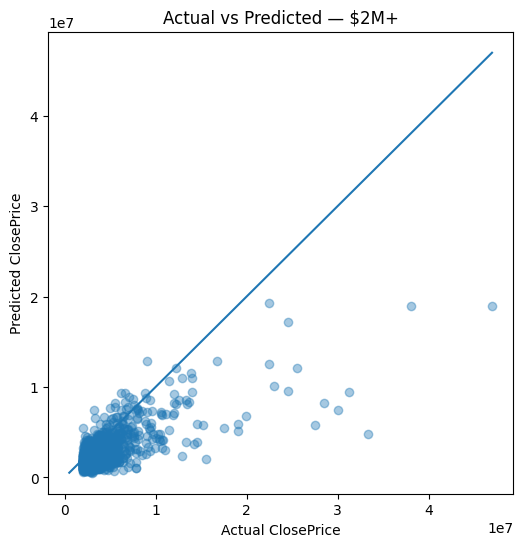

In [17]:
for band in price_labels:
    subset = eval_df[eval_df["PriceBand"] == band].copy()
    
    if len(subset) == 0:
        continue
    
    plt.figure(figsize=(6, 6))
    
    plt.scatter(
        subset["ClosePrice"],
        subset["PredictedClosePrice_XGB"],
        alpha=0.4
    )
    
    min_price = min(subset["ClosePrice"].min(), subset["PredictedClosePrice_XGB"].min())
    max_price = max(subset["ClosePrice"].max(), subset["PredictedClosePrice_XGB"].max())
    
    plt.plot([min_price, max_price], [min_price, max_price])
    
    plt.title(f"Actual vs Predicted — {band}")
    plt.xlabel("Actual ClosePrice")
    plt.ylabel("Predicted ClosePrice")
    plt.show()

In [18]:
focus_bands = ["$500K–$1M", "$1M–$2M"]

focus_df = eval_df[eval_df["PriceBand"].isin(focus_bands)].copy()

focus_metrics = regression_metrics(
    focus_df["ClosePrice"],
    focus_df["PredictedClosePrice_XGB"]
)

focus_metrics_df = pd.DataFrame([{
    "Segment": "$500K–$2M Focus Bands",
    **focus_metrics
}])

focus_metrics_df["MAPE_%"] = focus_metrics_df["MAPE"] * 100
focus_metrics_df["MdAPE_%"] = focus_metrics_df["MdAPE"] * 100

focus_metrics_df

,Segment,R2,MAPE,MdAPE,MAE,RMSE,Count,MAPE_%,MdAPE_%
0,$500K–$2M Focus Bands,0.311489,0.216817,0.168264,220988.633736,318956.017851,9299,21.681665,16.826373


In [19]:
focus_band_metrics = price_band_metrics[
    price_band_metrics["Segment"].isin(focus_bands)
].copy()

focus_band_metrics[
    ["Segment", "Count", "R2", "MAPE_%", "MdAPE_%", "MAE", "RMSE"]
]

,Segment,Count,R2,MAPE_%,MdAPE_%,MAE,RMSE
1,$500K–$1M,5312,-1.524153,21.615632,15.627394,155013.050473,222173.518672
2,$1M–$2M,3987,-1.360491,21.769643,18.338968,308889.887384,414137.123737


# Week 8 — Evaluation Expansion

For Week 8, I expanded the evaluation beyond overall R², MAPE, and MdAPE. The goal was to understand where the model performs better or worse across different price ranges.

Based on the team’s updated evaluation framework, I divided the June 2026 test set into four price bands:

- Under $500K
- $500K–$1M
- $1M–$2M
- $2M+

I also focused additional attention on the $500K–$1M and $1M–$2M bands because those represent a large share of the dataset and are likely the most important ranges for typical model performance.

In [20]:
metrics_summary = price_band_metrics.copy()

metrics_summary = metrics_summary[
    ["Segment", "Count", "R2", "MAPE", "MdAPE", "MAPE_%", "MdAPE_%", "MAE", "RMSE"]
]

metrics_summary = pd.concat(
    [overall_metrics_df[metrics_summary.columns], metrics_summary],
    ignore_index=True
)

# Save required Week 8 deliverable
metrics_summary.to_csv("metrics_summary.csv", index=False)

# Cleaner display version
metrics_summary_display = metrics_summary.copy()

metrics_summary_display["R2"] = metrics_summary_display["R2"].round(3)
metrics_summary_display["MAPE_%"] = metrics_summary_display["MAPE_%"].round(2)
metrics_summary_display["MdAPE_%"] = metrics_summary_display["MdAPE_%"].round(2)
metrics_summary_display["MAE"] = metrics_summary_display["MAE"].round(0)
metrics_summary_display["RMSE"] = metrics_summary_display["RMSE"].round(0)

metrics_summary_display[
    ["Segment", "Count", "R2", "MAPE_%", "MdAPE_%", "MAE", "RMSE"]
]

,Segment,Count,R2,MAPE_%,MdAPE_%,MAE,RMSE
0,Overall,12858,0.615,36.91,19.96,377141.0,952920.0
1,Under $500K,1767,-7.165,120.34,39.60,191243.0,254207.0
2,$500K–$1M,5312,-1.524,21.62,15.63,155013.0,222174.0
3,$1M–$2M,3987,-1.360,21.77,18.34,308890.0,414137.0
4,$2M+,1792,0.358,33.68,31.40,1370749.0,2433903.0


In [21]:
eval_df["PredictionError_XGB"] = (
    eval_df["PredictedClosePrice_XGB"] - eval_df["ClosePrice"]
)

eval_df["PercentError_XGB"] = (
    eval_df["PredictionError_XGB"] / eval_df["ClosePrice"]
)

eval_df["OverPredicted_XGB"] = (
    eval_df["PredictedClosePrice_XGB"] > eval_df["ClosePrice"]
).astype(int)

bias_summary = eval_df.groupby("PriceBand", observed=True).agg(
    count=("ClosePrice", "count"),
    median_actual_price=("ClosePrice", "median"),
    median_predicted_price=("PredictedClosePrice_XGB", "median"),
    median_prediction_error=("PredictionError_XGB", "median"),
    mean_prediction_error=("PredictionError_XGB", "mean"),
    median_percent_error=("PercentError_XGB", "median"),
    mean_percent_error=("PercentError_XGB", "mean"),
    overprediction_rate=("OverPredicted_XGB", "mean")
).reset_index()

bias_summary["median_percent_error_%"] = bias_summary["median_percent_error"] * 100
bias_summary["mean_percent_error_%"] = bias_summary["mean_percent_error"] * 100
bias_summary["overprediction_rate_%"] = bias_summary["overprediction_rate"] * 100

bias_summary_display = bias_summary.copy()

for col in [
    "median_actual_price",
    "median_predicted_price",
    "median_prediction_error",
    "mean_prediction_error"
]:
    bias_summary_display[col] = bias_summary_display[col].round(0)

bias_summary_display["median_percent_error_%"] = bias_summary_display["median_percent_error_%"].round(2)
bias_summary_display["mean_percent_error_%"] = bias_summary_display["mean_percent_error_%"].round(2)
bias_summary_display["overprediction_rate_%"] = bias_summary_display["overprediction_rate_%"].round(2)

bias_summary_display[
    [
        "PriceBand",
        "count",
        "median_actual_price",
        "median_predicted_price",
        "median_prediction_error",
        "median_percent_error_%",
        "overprediction_rate_%"
    ]
]

,PriceBand,count,median_actual_price,median_predicted_price,median_prediction_error,median_percent_error_%,overprediction_rate_%
0,Under $500K,1767,400000.0,535809.0,144427.0,39.60,91.06
1,$500K–$1M,5312,745000.0,807904.0,66809.0,9.19,67.15
2,$1M–$2M,3987,1350000.0,1192376.0,-160743.0,-11.95,30.20
3,$2M+,1792,2820000.0,2060949.0,-872704.0,-29.75,12.56


In [22]:
bias_summary.to_csv("price_band_bias_summary.csv", index=False)

print("Saved metrics_summary.csv")
print("Saved price_band_bias_summary.csv")

Saved metrics_summary.csv
Saved price_band_bias_summary.csv


In [23]:
focus_bands = ["$500K–$1M", "$1M–$2M"]

focus_df = eval_df[eval_df["PriceBand"].isin(focus_bands)].copy()

focus_metrics = regression_metrics(
    focus_df["ClosePrice"],
    focus_df["PredictedClosePrice_XGB"]
)

focus_metrics_df = pd.DataFrame([{
    "Segment": "$500K–$2M Focus Bands",
    **focus_metrics
}])

focus_metrics_df["MAPE_%"] = focus_metrics_df["MAPE"] * 100
focus_metrics_df["MdAPE_%"] = focus_metrics_df["MdAPE"] * 100
focus_metrics_df["Percent_of_Test_Set"] = len(focus_df) / len(eval_df) * 100

focus_metrics_display = focus_metrics_df.copy()

focus_metrics_display["R2"] = focus_metrics_display["R2"].round(3)
focus_metrics_display["MAPE_%"] = focus_metrics_display["MAPE_%"].round(2)
focus_metrics_display["MdAPE_%"] = focus_metrics_display["MdAPE_%"].round(2)
focus_metrics_display["MAE"] = focus_metrics_display["MAE"].round(0)
focus_metrics_display["RMSE"] = focus_metrics_display["RMSE"].round(0)
focus_metrics_display["Percent_of_Test_Set"] = focus_metrics_display["Percent_of_Test_Set"].round(2)

focus_metrics_display[
    ["Segment", "Count", "Percent_of_Test_Set", "R2", "MAPE_%", "MdAPE_%", "MAE", "RMSE"]
]

,Segment,Count,Percent_of_Test_Set,R2,MAPE_%,MdAPE_%,MAE,RMSE
0,$500K–$2M Focus Bands,9299,72.32,0.311,21.68,16.83,220989.0,318956.0


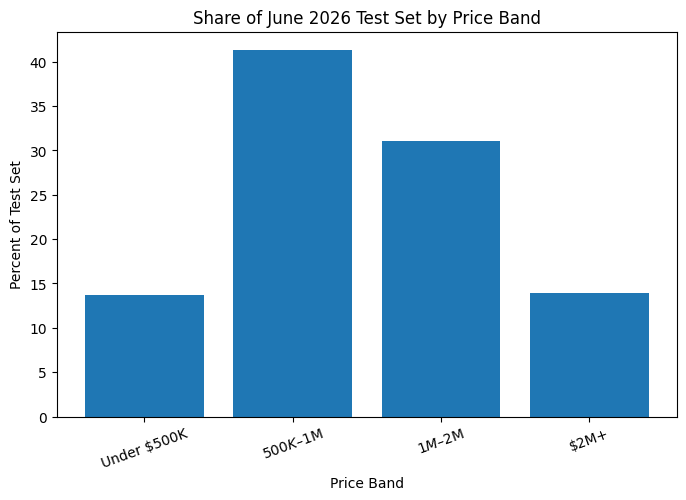

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    price_band_counts["PriceBand"].astype(str),
    price_band_counts["Percent"]
)

plt.title("Share of June 2026 Test Set by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Percent of Test Set")
plt.xticks(rotation=20)
plt.show()

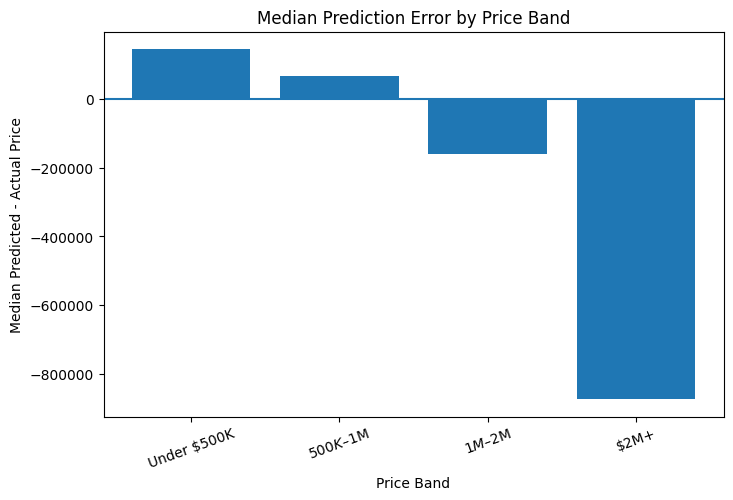

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    bias_summary["PriceBand"].astype(str),
    bias_summary["median_prediction_error"]
)

plt.axhline(0)

plt.title("Median Prediction Error by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Median Predicted - Actual Price")
plt.xticks(rotation=20)
plt.show()

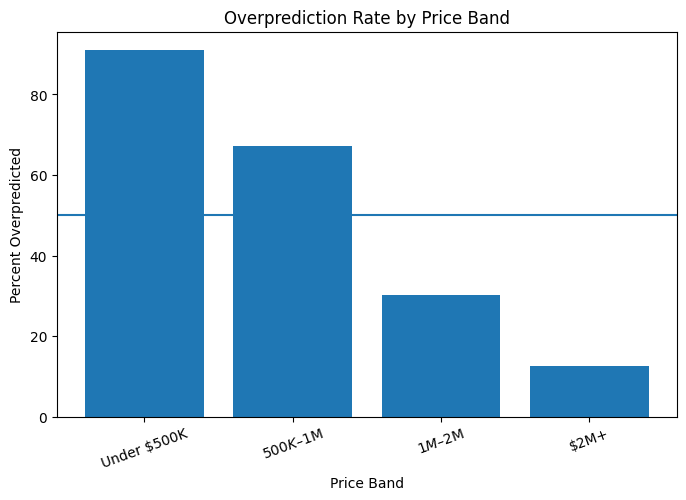

In [27]:
plt.figure(figsize=(8, 5))

plt.bar(
    bias_summary["PriceBand"].astype(str),
    bias_summary["overprediction_rate_%"]
)

plt.axhline(50)

plt.title("Overprediction Rate by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Percent Overpredicted")
plt.xticks(rotation=20)
plt.show()

### Note on Band-Level R²

Several band-level R² values are negative, especially in the narrower price bands. This does not necessarily mean the model is useless within those bands. R² compares the model against predicting the mean within that same subset, and once the data is split into narrow price ranges, there is much less variance in the actual prices for the model to explain.

Because of this, R² is less stable and less interpretable at the individual price-band level. For the band-level evaluation, MAPE, MdAPE, MAE, and prediction bias are more useful. MdAPE is especially helpful because it shows the typical percentage error within each band and is less distorted by extreme outliers than MAPE.

## Week 8 Findings

For Week 8, I expanded model evaluation beyond overall R², MAPE, and MdAPE by breaking the June 2026 test set into the team’s agreed price bands: under $500K, $500K–$1M, $1M–$2M, and $2M+.

The overall XGBoost model remained the strongest model so far, with an overall R² of about 0.615, MAPE of about 36.91%, and MdAPE of about 19.96%.

The price-band distribution supports the team’s decision to focus on the $500K–$1M and $1M–$2M ranges. These two bands make up about 72% of the June 2026 test set, with 41.3% of properties in the $500K–$1M band and 31.0% in the $1M–$2M band. This means performance in these middle bands is most representative of the majority of the dataset.

The model performs best in the middle price ranges. In the $500K–$1M band, MdAPE is about 15.63%, and in the $1M–$2M band, MdAPE is about 18.34%. These are much better than the under $500K band, where MdAPE is about 39.60%, and the $2M+ band, where MdAPE is about 31.40%.

This suggests that the model is most reliable for typical residential sale prices and less reliable at the low and high ends of the market. The under $500K band may include more unusual or nonstandard transactions, and percentage errors become larger when the actual sale price is small. The $2M+ band may be harder because high-end homes often depend on luxury-specific details that are not fully captured in the current feature set, such as views, renovations, architecture, waterfront access, privacy, amenities, or micro-location.

The prediction-bias diagnostics are also useful. If the median prediction error is positive in a band, the model tends to overpredict that range; if it is negative, the model tends to underpredict that range. This helps identify whether the model is systematically too high or too low for certain parts of the market, rather than only measuring the size of the error.

Overall, the Week 8 evaluation shows that the model should not be judged only by one overall metric. XGBoost performs well overall, but its reliability varies meaningfully by price band. The model is strongest in the $500K–$2M focus range, which represents most of the dataset, while the lowest and highest price bands remain the main areas for future improvement.